In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
performance_statistics_no_aug = pd.read_csv('/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/singan-augmentation-experiments/singan-augmentation-2025-07-03T05-38-25/unet_performance_statistics_0.csv')

In [4]:
original_dice_coefficients = {
    "FD-032": 0.4782,
    "FD-030": 0.7102,
    "FD-027": 0.7316,
    "FD-029": 0.7198,
    "FD-031": 0.6249,
}

In [5]:
new_dice_coefficients = performance_statistics_no_aug[['final_dice_coefficient', 'cv_subject', 'dice_coefficients', 'num_val_samples']]

In [6]:
import ast
new_dice_coefficients['dice_coefficients'] = new_dice_coefficients['dice_coefficients'].apply(ast.literal_eval)

/tmp/ipykernel_2130612/1887549971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dice_coefficients['dice_coefficients'] = new_dice_coefficients['dice_coefficients'].apply(ast.literal_eval)


In [7]:
new_dice_coefficients['dice_coefficient_std'] = new_dice_coefficients['dice_coefficients'].apply(lambda x: pd.Series(x).std())

/tmp/ipykernel_2130612/3800380390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dice_coefficients['dice_coefficient_std'] = new_dice_coefficients['dice_coefficients'].apply(lambda x: pd.Series(x).std())


In [8]:
new_dice_coefficients

,final_dice_coefficient,cv_subject,dice_coefficients,num_val_samples,dice_coefficient_std
0,0.672110,FD-030,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",72,0.407065
1,0.739106,FD-027,"[1.0, 1.0, 1.0, 1.0, 3.1249999921101335e-08, 8...",72,0.306587
2,0.682231,FD-029,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.4204545317753...",72,0.325007
3,0.568878,FD-032,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",72,0.405044
4,0.860301,FD-031,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",72,0.163597


In [9]:
import numpy as np

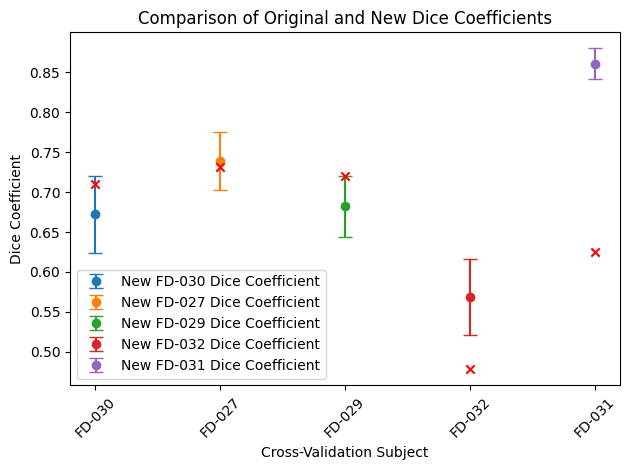

In [10]:
for cv_subject in new_dice_coefficients['cv_subject'].unique():

    cv_subject_data = new_dice_coefficients[new_dice_coefficients['cv_subject'] == cv_subject]

    final_dice_coefficient = cv_subject_data['final_dice_coefficient'].values[0]
    dice_coefficient_std = cv_subject_data['dice_coefficient_std'].values[0]
    num_samples = cv_subject_data['num_val_samples'].values[0]

    # Draw error bars
    plt.errorbar(
        cv_subject,
        final_dice_coefficient,
        yerr=dice_coefficient_std / np.sqrt(num_samples),
        fmt='o',
        label=f'New {cv_subject} Dice Coefficient',
        capsize=5
    )

    plt.scatter(
        cv_subject,
        original_dice_coefficients[cv_subject],
        color='red',
        zorder=5,
        marker='x',
    )
plt.title('Comparison of Original and New Dice Coefficients')
plt.xlabel('Cross-Validation Subject')
plt.ylabel('Dice Coefficient')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



In [11]:
new_dice_coefficients['final_dice_coefficient'].mean()

np.float64(0.7045253266284295)

In [12]:
old_mean = pd.Series(original_dice_coefficients).mean()

In [13]:
# Perform a t-test for statistical significance

In [27]:
all_dice_coefficients = np.concatenate(new_dice_coefficients['dice_coefficients'].values)
mean_dice = np.mean(all_dice_coefficients)
stderr = np.std(all_dice_coefficients) / np.sqrt(len(all_dice_coefficients))

In [29]:
old_mean

np.float64(0.6529400000000001)

In [28]:
mean_dice

np.float64(0.7045253266284295)

In [15]:
import scipy.stats as stats

# ── Inputs ─────────────────────────────────────────────────────────────────────
# mean_dice = your sample mean
# stderr    = your standard error of the mean
#───────────────────────────────────────────────────────────────────────────────

z_stat = (mean_dice - old_mean) / stderr
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

alpha = 0.05

print(f"z = {z_stat:.3f}, p = {p_value:.3f}")
if p_value < alpha:
    print("→ Reject H₀: population mean ≠ 0.65")
else:
    print("→ Fail to reject H₀: insufficient evidence that mean ≠ 0.65")

z = 2.840, p = 0.005
→ Reject H₀: population mean ≠ 0.65


In [16]:
z_stat

np.float64(2.8400683489259277)

In [17]:
# Analyze the Singan augmentation results, and compare with the vanilla UNet

In [18]:
augmented_stats_df_1 = pd.read_csv('/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/singan-augmentation-experiments/singan-augmentation-2025-07-03T02-11-31/unet_performance_statistics_16.csv')
augmented_stats_df_2 = pd.read_csv('/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/singan-augmentation-experiments/singan-augmentation-2025-07-03T04-15-59/unet_performance_statistics_16.csv')

In [19]:
augmented_stats_df = pd.concat([augmented_stats_df_1, augmented_stats_df_2], ignore_index=True)

In [20]:
augmented_stats_df['num_train_samples_rounded_to_100'] = augmented_stats_df['num_train_samples'].apply(lambda x: round(x, -2))

augmented_stats_df.loc[augmented_stats_df[augmented_stats_df['num_train_samples_rounded_to_100'] == 4400].index, 'num_train_samples_rounded_to_100'] = 4500
augmented_stats_df.loc[augmented_stats_df[augmented_stats_df['num_train_samples_rounded_to_100'] == 4600].index, 'num_train_samples_rounded_to_100'] = 4500

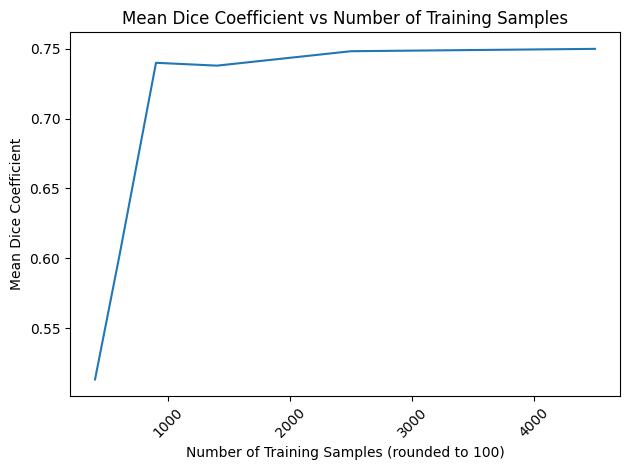

In [21]:
plt.plot(augmented_stats_df.groupby('num_train_samples_rounded_to_100')['final_dice_coefficient'].mean())
plt.ylabel('Mean Dice Coefficient')
plt.xlabel('Number of Training Samples (rounded to 100)')
plt.title('Mean Dice Coefficient vs Number of Training Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
augmented_stats_df.groupby('num_train_samples_rounded_to_100')['final_dice_coefficient'].mean()

num_train_samples_rounded_to_100
400     0.513436
600     0.601934
900     0.739845
1400    0.737808
2500    0.748126
4500    0.749803
Name: final_dice_coefficient, dtype: float64

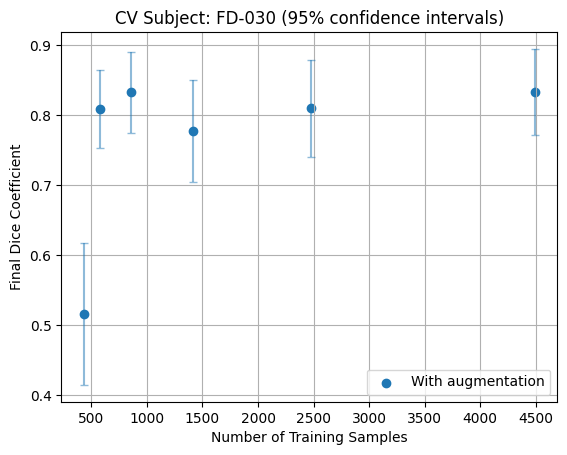

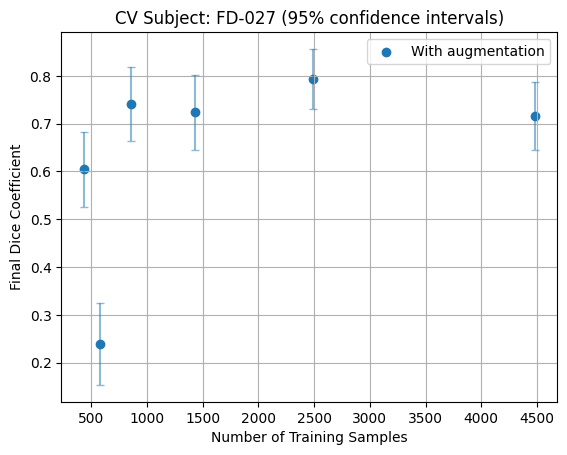

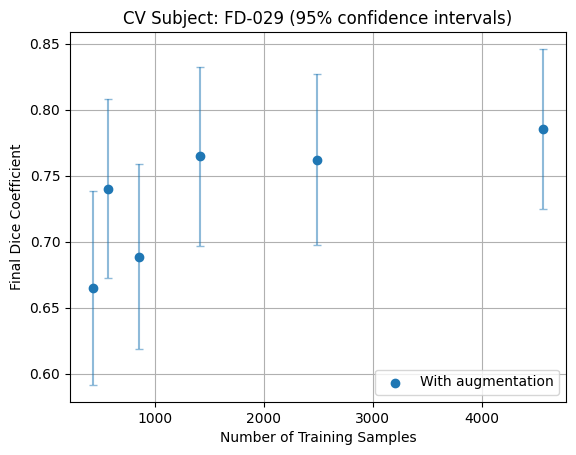

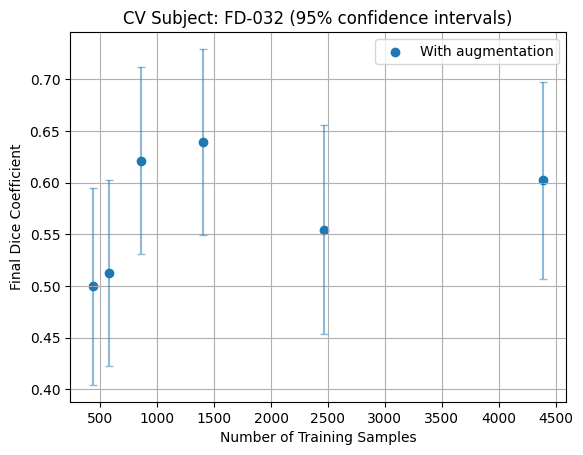

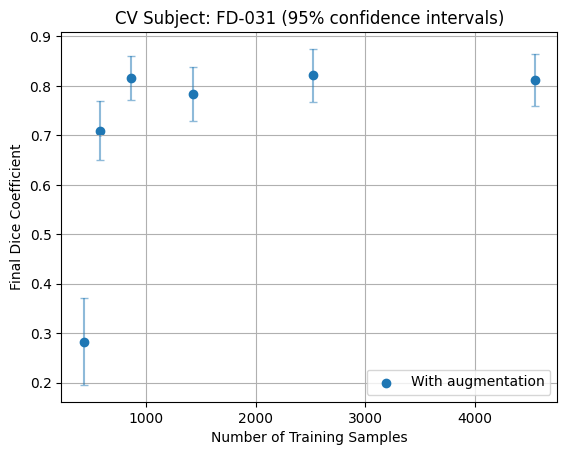

In [23]:
cv_improvement = []
z = 2

for cv_subject in augmented_stats_df['cv_subject'].unique():
    subject_df = augmented_stats_df[augmented_stats_df['cv_subject'] == cv_subject]


    se = subject_df['final_dice_coefficient_std'].values / np.sqrt(subject_df['num_val_samples'].values)
    margin = z * se
    plt.scatter(subject_df['num_train_samples'].values, subject_df['final_dice_coefficient'].values, label="With augmentation")

    # add vertical error‐bars
    plt.errorbar(
        subject_df['num_train_samples'].values, 
        subject_df['final_dice_coefficient'].values,
        yerr=margin,
        fmt='none',
        ecolor='C0',
        alpha=0.5,
        capsize=3
    )


    plt.xlabel('Number of Training Samples')
    plt.ylabel('Final Dice Coefficient')
    plt.title(f'CV Subject: {cv_subject} (95% confidence intervals)')
    plt.legend()
    plt.grid(True)
    plt.show()


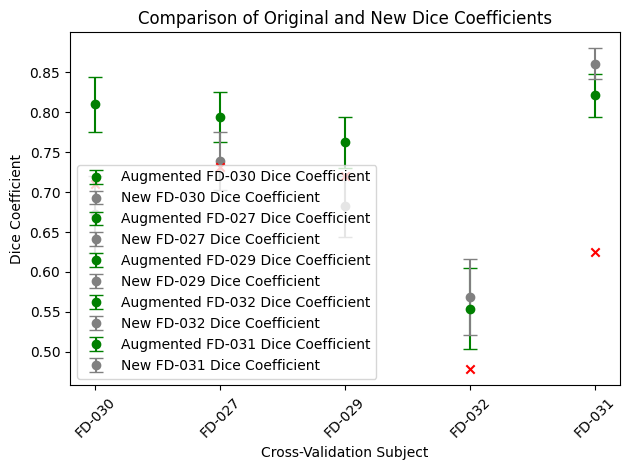

In [24]:
for cv_subject in new_dice_coefficients['cv_subject'].unique():

    cv_subject_data = new_dice_coefficients[new_dice_coefficients['cv_subject'] == cv_subject]

    final_dice_coefficient = cv_subject_data['final_dice_coefficient'].values[0]
    dice_coefficient_std = cv_subject_data['dice_coefficient_std'].values[0]
    num_samples = cv_subject_data['num_val_samples'].values[0]

    cv_subject_data = augmented_stats_df[(augmented_stats_df['cv_subject'] == cv_subject) & (augmented_stats_df['num_train_samples_rounded_to_100'] == 2500)]

    final_dice_coefficient_mean = cv_subject_data['final_dice_coefficient'].values[0]
    final_dice_coefficient_std = cv_subject_data['final_dice_coefficient_std'].values[0]
    num_val_samples = cv_subject_data['num_val_samples'].values[0]

    plt.errorbar(
        cv_subject,
        final_dice_coefficient_mean,
        yerr=final_dice_coefficient_std / np.sqrt(num_val_samples),
        fmt='o',
        label=f'Augmented {cv_subject} Dice Coefficient',
        capsize=5,
        color='green'
    )


    # Draw error bars
    plt.errorbar(
        cv_subject,
        final_dice_coefficient,
        yerr=dice_coefficient_std / np.sqrt(num_samples),
        fmt='o',
        label=f'New {cv_subject} Dice Coefficient',
        capsize=5,
        color="gray"
    )

    plt.scatter(
        cv_subject,
        original_dice_coefficients[cv_subject],
        color='red',
        zorder=5,
        marker='x',
    )
plt.title('Comparison of Original and New Dice Coefficients')
plt.xlabel('Cross-Validation Subject')
plt.ylabel('Dice Coefficient')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



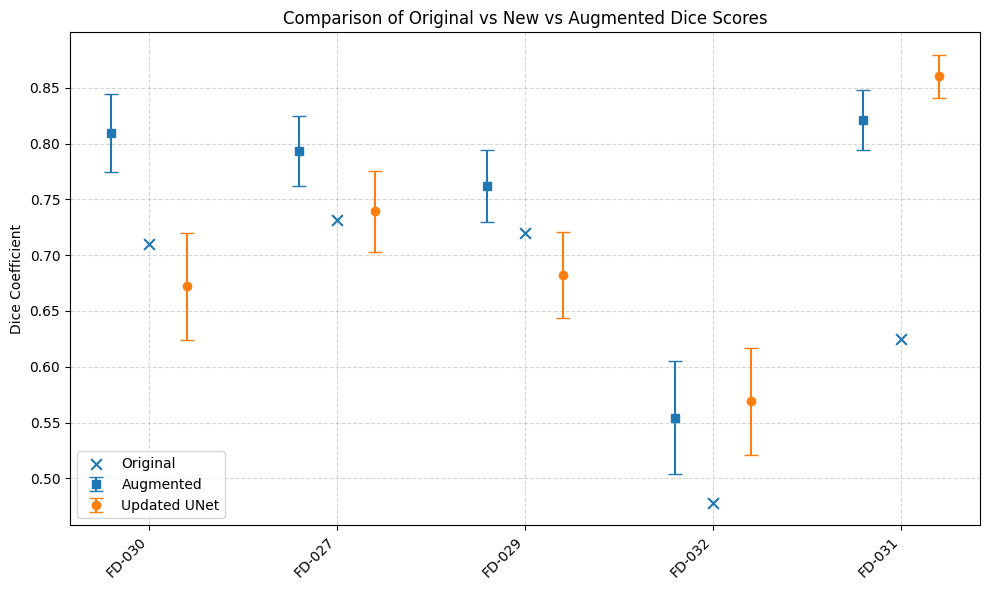

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. get your ordered list of subjects
subjects = list(new_dice_coefficients['cv_subject'].unique())
x = np.arange(len(subjects))

# how far apart to shift the two error‐bars
offset = 0.2

# start the figure
fig, ax = plt.subplots(figsize=(10, 6))

# plot the "Augmented" errorbars
aug_x = x - offset
aug_means, aug_stds, aug_ns = [], [], []
for subj in subjects:
    row = augmented_stats_df[
        (augmented_stats_df['cv_subject']==subj) &
        (augmented_stats_df['num_train_samples_rounded_to_100']==2500)
    ].iloc[0]
    aug_means.append(row['final_dice_coefficient'])
    aug_stds.append(row['final_dice_coefficient_std'])
    aug_ns.append(row['num_val_samples'])
    
ax.errorbar(
    aug_x,
    aug_means,
    yerr=[s/np.sqrt(n) for s,n in zip(aug_stds, aug_ns)],
    fmt='s', capsize=5, label='Augmented', markersize=6
)

# plot the "New" errorbars
new_x = x + offset
new_means, new_stds, new_ns = [], [], []
for subj in subjects:
    row = new_dice_coefficients[new_dice_coefficients['cv_subject']==subj].iloc[0]
    new_means.append(row['final_dice_coefficient'])
    new_stds.append(row['dice_coefficient_std'])
    new_ns.append(row['num_val_samples'])

ax.errorbar(
    new_x,
    new_means,
    yerr=[s/np.sqrt(n) for s,n in zip(new_stds, new_ns)],
    fmt='o', capsize=5, label='Updated UNet', markersize=6
)

# plot the original single values
orig_vals = [ original_dice_coefficients[subj] for subj in subjects ]
ax.scatter(
    x,
    orig_vals,
    marker='x', s=60, label='Original', zorder=5
)

# formatting
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Dice Coefficient')
ax.set_title('Comparison of Original vs New vs Augmented Dice Scores')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


In [31]:
all_dice_coefficients = np.concatenate(new_dice_coefficients['dice_coefficients'].values)
mean_dice = np.mean(all_dice_coefficients)
stderr = np.std(all_dice_coefficients) / np.sqrt(len(all_dice_coefficients))

In [32]:
mean_dice

np.float64(0.7045253266284295)

In [33]:
dice_coefficients_parsed

NameError: name 'dice_coefficients_parsed' is not defined

In [34]:
augmented_stats_df_best_sample = augmented_stats_df[augmented_stats_df['num_train_samples_rounded_to_100'] == 2500]

In [35]:
# Compute the mean dice and standard error of the augmented results
dice_coefficients_parsed = augmented_stats_df_best_sample['dice_coefficients'].apply(lambda x: np.array(ast.literal_eval(x))).values.tolist()
augmented_dice_coefficients = np.concatenate(dice_coefficients_parsed)
augmented_mean_dice = np.mean(augmented_dice_coefficients)
augmented_stderr = np.std(augmented_dice_coefficients) / np.sqrt(len(augmented_dice_coefficients))

In [36]:
augmented_mean_dice

np.float64(0.7481260694561784)

In [37]:
import scipy.stats as stats

# ── Inputs ─────────────────────────────────────────────────────────────────────
# mean_dice = your sample mean
# stderr    = your standard error of the mean
#───────────────────────────────────────────────────────────────────────────────

z_stat = (augmented_mean_dice - mean_dice) / augmented_stderr
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

alpha = 0.05

print(f"z = {z_stat:.3f}, p = {p_value:.3f}")
if p_value < alpha:
    print("→ Reject H₀: population mean ≠ 0.65")
else:
    print("→ Fail to reject H₀: insufficient evidence that mean ≠ 0.65")

z = 2.570, p = 0.010
→ Reject H₀: population mean ≠ 0.65
